In [ ]:
import os, sys
from pathlib import Path

# Navigate to project root (parent of notebooks/)
_cwd = Path().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

Path('outputs/models').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

print("✅ Ready. Artifacts found:")
for f in Path('outputs').glob('*.parquet'):
    print(f"  {f.name}  ({f.stat().st_size / 1024 / 1024:.1f} MB)")

In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.model_selection import cross_val_score, GroupShuffleSplit, train_test_split
from xgboost import XGBClassifier

### 03_3 — Hyperparameter Tuning: RF & XGBoost

In this section, we use **Optuna** to find the optimal hyperparameters for our models.
Cross-validation (CV) is performed within the Optuna objective function, ensuring that the test set (`X_test`) remains untouched until the final evaluation.

**Strategy:**
- **Efficiency:** Use a 20% stratified subsample of the training data for faster search.
- **Leakage Prevention:** Use `GroupShuffleSplit` within CV to ensure data from the same source (well) doesn't appear in both training and validation folds.
- **Final Training:** Once the best parameters are found, train the final model on the entire training set.
- **Goal:** Optimize for high ROC-AUC while being mindful of False Negatives (missed anomalies).

In [ ]:
df_feat_train = pd.read_parquet("outputs/features_train.parquet")
df_feat_test  = pd.read_parquet("outputs/features_test.parquet")

DEAD_FEATURES = ["P-PDG_mean", "P-PDG_std", "P-PDG_min",
                 "P-PDG_max", "P-PDG_range", "P-PDG_trend"]

feature_cols = [c for c in df_feat_train.columns
                if c not in ("label", "event_type", "source")
                and c not in DEAD_FEATURES]

X_train = df_feat_train[feature_cols].values
y_train = df_feat_train["label"].values
X_test  = df_feat_test[feature_cols].values
y_test  = df_feat_test["label"].values

with open("outputs/models/random_forest_baseline.pkl", "rb") as f:
    rf_baseline = pickle.load(f)
with open("outputs/models/xgboost_baseline.pkl", "rb") as f:
    xgb_baseline = pickle.load(f)

print(f"Features:      {len(feature_cols)}")
print(f"Train windows: {len(X_train):,}  |  anomaly rate: {y_train.mean()*100:.1f}%")
print(f"Test windows:  {len(X_test):,}  |  anomaly rate: {y_test.mean()*100:.1f}%")

Features:      24
Train windows: 662,805  |  anomaly rate: 41.3%
Test windows:  172,016  |  anomaly rate: 49.1%


## 1. Optuna — Random Forest

In [ ]:
# Use 20% of the training data for hyperparameter optimization to save time
idx_opt, _ = train_test_split(
    range(len(X_train)), train_size=0.2, random_state=42, stratify=y_train
)
X_opt      = X_train[idx_opt]
y_opt      = y_train[idx_opt]
groups_opt = df_feat_train["source"].values[idx_opt]

# GroupShuffleSplit ensures that windows from the same original file (source)
# are not split between training and validation during CV folds
cv_opt = GroupShuffleSplit(n_splits=2, test_size=0.2, random_state=42)

def rf_objective(trial):
    # Define the search space for Random Forest hyperparameters
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 300),
        "max_depth":        trial.suggest_int("max_depth", 10, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":     trial.suggest_categorical("max_features", ["sqrt", 0.5]),
        "random_state":     42,
        "class_weight":     "balanced",
        "n_jobs":           -1,
    }
    rf = RandomForestClassifier(**params)
    # Evaluate the configuration using the mean ROC-AUC across CV folds
    scores = cross_val_score(rf, X_opt, y_opt, groups=groups_opt,
                             cv=cv_opt, scoring="roc_auc")
    return scores.mean()

print("Running Optuna for Random Forest (20 trials)...")

sampler = optuna.samplers.TPESampler(seed=42)

rf_study = optuna.create_study(direction="maximize", sampler=sampler)
rf_study.optimize(rf_objective, n_trials=20, show_progress_bar=True)

print(f"\nBest ROC-AUC (CV): {rf_study.best_value:.4f}")
print(f"Best params:")
for k, v in rf_study.best_params.items():
    print(f"  {k}: {v}")

Running Optuna for Random Forest (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


Best ROC-AUC (CV): 0.9805
Best params:
  n_estimators: 257
  max_depth: 14
  min_samples_leaf: 6
  max_features: sqrt


In [ ]:
rf_tuned_params = {
    **rf_study.best_params,
    "random_state": 42,
    "class_weight": "balanced",
    "n_jobs":       -1,
}

print("Training tuned RF on full X_train...")
rf_tuned = RandomForestClassifier(**rf_tuned_params)
rf_tuned.fit(X_train, y_train)

with open("outputs/models/random_forest_tuned.pkl", "wb") as f:
    pickle.dump(rf_tuned, f)

y_pred_rf_tuned  = rf_tuned.predict(X_test)
y_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]
roc_rf_tuned     = roc_auc_score(y_test, y_proba_rf_tuned)
cm_rf_tuned      = confusion_matrix(y_test, y_pred_rf_tuned)

print("\n=== RF Tuned ===")
print(classification_report(y_test, y_pred_rf_tuned,
                             target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC : {roc_rf_tuned:.4f}")
print(f"FN      : {cm_rf_tuned[1,0]}  (missed anomalies)")
print(f"FP      : {cm_rf_tuned[0,1]}  (false alarms)")

roc_train = roc_auc_score(y_train, rf_tuned.predict_proba(X_train)[:, 1])
print(f"\nTrain ROC-AUC: {roc_train:.4f}  |  Test: {roc_rf_tuned:.4f}  |  Gap: {roc_train - roc_rf_tuned:+.4f}")

Training tuned RF on full X_train...

=== RF Tuned ===
              precision    recall  f1-score   support

      Normal       0.91      0.90      0.90     87601
     Anomaly       0.90      0.91      0.90     84415

    accuracy                           0.90    172016
   macro avg       0.90      0.90      0.90    172016
weighted avg       0.90      0.90      0.90    172016

ROC-AUC : 0.9633
FN      : 7787  (missed anomalies)
FP      : 8947  (false alarms)

Train ROC-AUC: 0.9987  |  Test: 0.9633  |  Gap: +0.0354


## 2. Optuna — XGBoost

In [ ]:
# Calculate scale_pos_weight to handle class imbalance in XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def xgb_objective(trial):
    # Define the search space for XGBoost hyperparameters
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 400),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": pos_weight,
        "random_state":     42,
        "eval_metric":      "logloss",
        "verbosity":        0,
    }
    xgb = XGBClassifier(**params)
    # Cross-validation within the optimization loop
    scores = cross_val_score(xgb, X_opt, y_opt, groups=groups_opt,
                             cv=cv_opt, scoring="roc_auc")
    return scores.mean()

print("Running Optuna for XGBoost (20 trials)...")

# Use the same TPE sampler defined previously
xgb_study = optuna.create_study(direction="maximize", sampler=sampler)
xgb_study.optimize(xgb_objective, n_trials=20, show_progress_bar=True)

print(f"\nBest ROC-AUC (CV): {xgb_study.best_value:.4f}")
print(f"Best params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")

Running Optuna for XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


Best ROC-AUC (CV): 0.9773
Best params:
  n_estimators: 292
  max_depth: 8
  learning_rate: 0.03767504083020753
  subsample: 0.8346213058823359
  colsample_bytree: 0.9100913116670417


In [ ]:
xgb_tuned_params = {
    **xgb_study.best_params,
    "scale_pos_weight": pos_weight,
    "random_state":     42,
    "eval_metric":      "logloss",
    "verbosity":        0,
}

print("Training tuned XGBoost on full X_train...")
xgb_tuned = XGBClassifier(**xgb_tuned_params)
xgb_tuned.fit(X_train, y_train)

with open("outputs/models/xgboost_tuned.pkl", "wb") as f:
    pickle.dump(xgb_tuned, f)

y_pred_xgb_tuned  = xgb_tuned.predict(X_test)
y_proba_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
roc_xgb_tuned     = roc_auc_score(y_test, y_proba_xgb_tuned)
cm_xgb_tuned      = confusion_matrix(y_test, y_pred_xgb_tuned)

print("\n=== XGBoost Tuned ===")
print(classification_report(y_test, y_pred_xgb_tuned,
                             target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC : {roc_xgb_tuned:.4f}")
print(f"FN      : {cm_xgb_tuned[1,0]}  (missed anomalies)")
print(f"FP      : {cm_xgb_tuned[0,1]}  (false alarms)")

roc_train_xgb = roc_auc_score(y_train, xgb_tuned.predict_proba(X_train)[:, 1])
print(f"\nTrain ROC-AUC: {roc_train_xgb:.4f}  |  Test: {roc_xgb_tuned:.4f}  |  Gap: {roc_train_xgb - roc_xgb_tuned:+.4f}")

Training tuned XGBoost on full X_train...

=== XGBoost Tuned ===
              precision    recall  f1-score   support

      Normal       0.88      0.91      0.89     87601
     Anomaly       0.90      0.87      0.89     84415

    accuracy                           0.89    172016
   macro avg       0.89      0.89      0.89    172016
weighted avg       0.89      0.89      0.89    172016

ROC-AUC : 0.9588
FN      : 10655  (missed anomalies)
FP      : 8210  (false alarms)

Train ROC-AUC: 0.9991  |  Test: 0.9588  |  Gap: +0.0403


## 3. Final Comparison: Baseline vs Tuned

In [ ]:
print(f"{'Model':<25} {'ROC-AUC':>8} {'F1-macro':>9} {'FN':>7} {'FP':>7}")
print("─" * 60)

models = [
    ("RF Baseline",    rf_baseline,    None,            None),
    ("RF Tuned",       rf_tuned,       y_pred_rf_tuned, y_proba_rf_tuned),
    ("XGBoost Baseline", xgb_baseline, None,            None),
    ("XGBoost Tuned",  xgb_tuned,      y_pred_xgb_tuned, y_proba_xgb_tuned),
]

results = []
for name, model, y_pred, y_proba in models:
    if y_pred is None:
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred, average="macro")
    cm  = confusion_matrix(y_test, y_pred)
    fn, fp = cm[1,0], cm[0,1]
    results.append((name, roc, f1, fn, fp))
    print(f"{name:<25} {roc:>8.4f} {f1:>9.4f} {fn:>7} {fp:>7}")

Model                      ROC-AUC  F1-macro      FN      FP
────────────────────────────────────────────────────────────
RF Baseline                 0.9616    0.8961   11649    6182
RF Tuned                    0.9633    0.9027    7787    8947
XGBoost Baseline            0.9658    0.8926   12051    6367
XGBoost Tuned               0.9588    0.8902   10655    8210


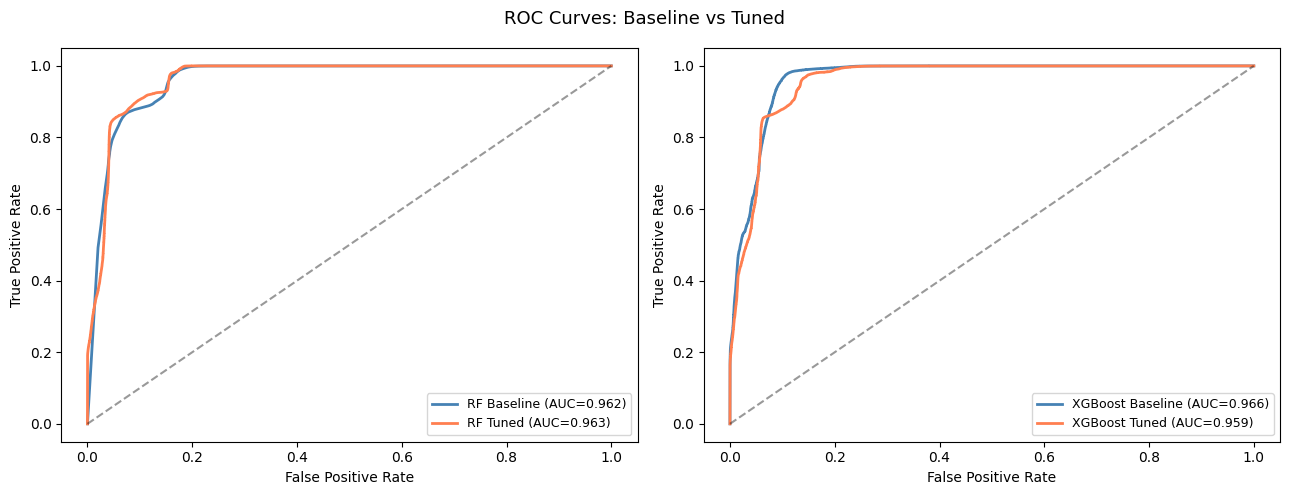

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (base_name, base_model, tune_name, tune_proba) in zip(axes, [
    ("RF Baseline",      rf_baseline,  "RF Tuned",      y_proba_rf_tuned),
    ("XGBoost Baseline", xgb_baseline, "XGBoost Tuned", y_proba_xgb_tuned),
]):
    base_proba = base_model.predict_proba(X_test)[:, 1]
    for name, proba, color in [
        (base_name, base_proba,  "steelblue"),
        (tune_name, tune_proba,  "coral"),
    ]:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1],"k--", alpha=0.4)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=9)

plt.suptitle("ROC Curves: Baseline vs Tuned", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figures/tuned_roc_curves.png", dpi=150)
plt.show()

In [ ]:
print("✅ All outputs saved locally to outputs/")
for f in sorted(Path('outputs/models').glob('*.pkl')):
    print(f"  models/{f.name}  ({f.stat().st_size / 1024 / 1024:.1f} MB)")
for f in sorted(Path('outputs/figures').glob('*.png')):
    print(f"  figures/{f.name}")

### 4. Additional Analysis: Feature Importance and Confusion Matrices

To understand why the models are making their decisions, we visualize the contribution of each feature and examine the distribution of errors.

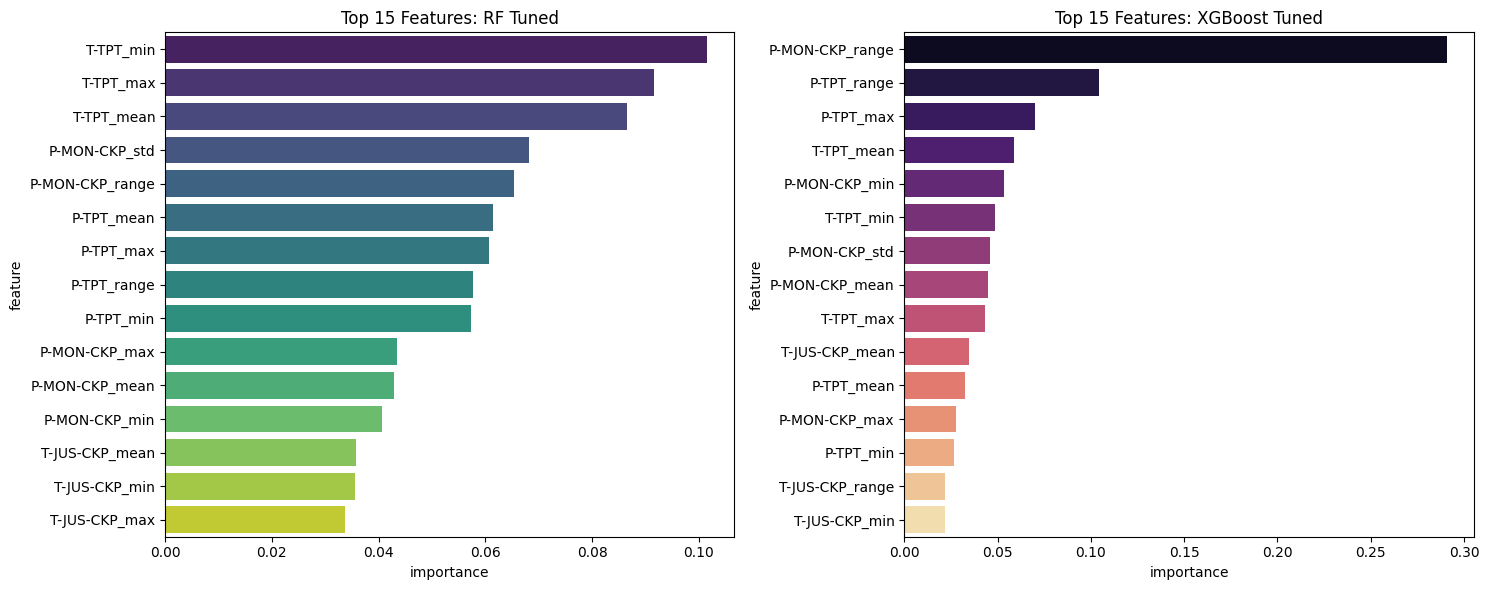

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for feature importance visualization
feat_imp_rf = pd.DataFrame({'feature': feature_cols, 'importance': rf_tuned.feature_importances_}).sort_values('importance', ascending=False)
feat_imp_xgb = pd.DataFrame({'feature': feature_cols, 'importance': xgb_tuned.feature_importances_}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot the Top 15 most important features for Random Forest
sns.barplot(x='importance', y='feature', data=feat_imp_rf.head(15), ax=axes[0], palette='viridis', hue='feature', legend=False)
axes[0].set_title('Top 15 Features: RF Tuned')

# Plot the Top 15 most important features for XGBoost
sns.barplot(x='importance', y='feature', data=feat_imp_xgb.head(15), ax=axes[1], palette='magma', hue='feature', legend=False)
axes[1].set_title('Top 15 Features: XGBoost Tuned')

plt.tight_layout()
plt.show()

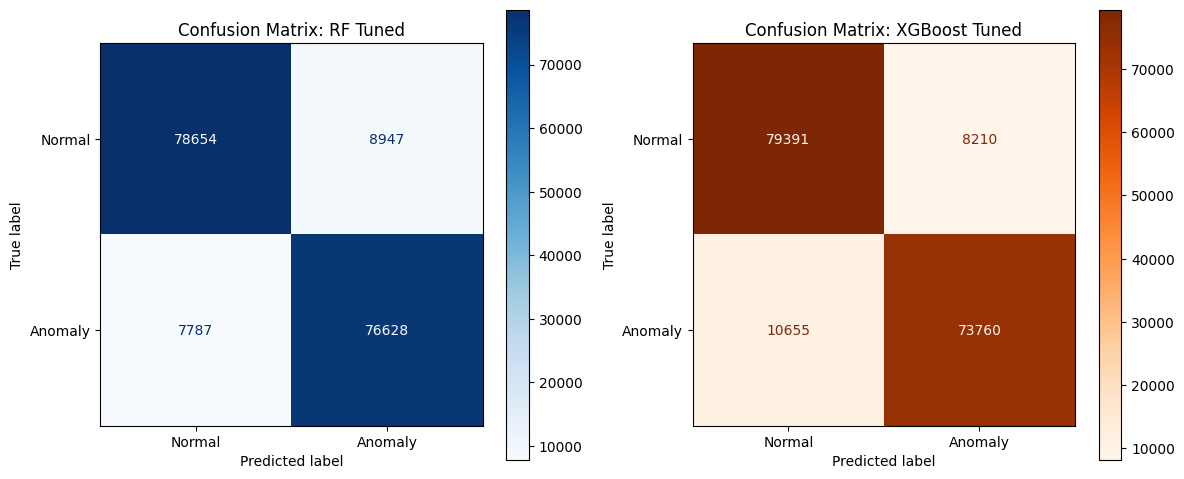

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_tuned,
                                        display_labels=['Normal', 'Anomaly'],
                                        cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: RF Tuned')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_tuned,
                                        display_labels=['Normal', 'Anomaly'],
                                        cmap='Oranges', ax=axes[1])
axes[1].set_title('Confusion Matrix: XGBoost Tuned')

plt.tight_layout()
plt.show()